# Predicting Clinical Trial Outcomes from Protocol Text

**A classical machine learning approach**

Machine Learning final project, May 2026.

---

## 1. Introduction

A clinical trial is a scientific study that tests whether a medical intervention
(a drug, a device, a behavioural program) is safe and effective in people. Before
a trial starts, its sponsor publishes a **protocol**: a structured document that
describes the condition under study, the intervention, who can take part
(the eligibility criteria), and what will be measured.

Many trials never reach a successful conclusion. Some are **terminated**,
**withdrawn**, or **suspended** because of low enrollment, safety concerns,
funding problems, or strategic decisions. A trial that stops early wastes money,
delays useful treatments, and exposes participants to risk without producing
usable evidence.

This project asks a simple but practical question:

> **Can we predict, from the information available about a trial, whether it will
> be *completed* or *terminated/withdrawn/suspended*?**

We treat this as a **binary text + tabular classification** problem and solve it
with classical machine learning models.

## 2. Problem formulation

### 2.1 Why this matters

- **Cost.** A single late-phase clinical trial can cost tens or hundreds of
  millions of dollars. Early warning that a trial is at risk lets sponsors
  reallocate resources.
- **Patients.** Participants accept risk by enrolling. A trial that stops without
  producing evidence breaks the implicit contract with them.
- **Evidence.** Terminated trials rarely publish results, creating gaps and bias
  in the medical literature.

Potential users of such a model include trial sponsors, contract research
organisations, regulators, and investors performing due diligence.

### 2.2 The learning task

Each example is a single trial. The label is derived from the trial's
`overall_status`:

$$
y =
\begin{cases}
1 & \text{if status} = \texttt{COMPLETED} \\
0 & \text{if status} \in \{\texttt{TERMINATED}, \texttt{WITHDRAWN}, \texttt{SUSPENDED}\}
\end{cases}
$$

Trials with non-final statuses (e.g. `RECRUITING`, `ACTIVE`) are excluded, because
their outcome is not yet known.

### 2.3 Assumptions and constraints

- The protocol text and metadata are written largely **before** the outcome is
  known. This is what makes prediction meaningful.
- **Data leakage risk.** In practice, records of terminated trials are often
  updated *after* the fact, and may contain explicit phrases such as
  *"study was terminated due to low enrollment"*. Using such text would let the
  model read the answer instead of predicting it. We address this explicitly in
  the preprocessing section.
- The dataset is in English only; findings may not transfer to other registries.

## 3. Data source and ethics

### 3.1 Source

Data comes from [**ClinicalTrials.gov**](https://clinicaltrials.gov/), the public
registry maintained by the U.S. National Library of Medicine. We use its
[API v2](https://clinicaltrials.gov/data-api/api), which returns study records as
structured JSON.

The download is handled by [`src/fetch_data.py`](../src/fetch_data.py), which keeps
only the fields we need and stores them as a local CSV:

```bash
python -m src.fetch_data --limit 2000 --output data/raw/trials.csv
```

For each trial we keep the text fields (`brief_summary`, `detailed_description`,
`eligibility_criteria`), tabular fields (`study_type`, `phase`,
`enrollment_count`, `conditions`, `intervention_types`), the label source
(`overall_status`), and `why_stopped` (kept **only** for leakage analysis, never
used as a feature).

### 3.2 Legal and ethical notes

- The registry is **public** and contains **no personally identifiable patient
  data (no PHI)**.
- Raw data is **not** committed to the repository. Only the download script is
  versioned, so anyone can reproduce the dataset. This follows good practice for
  data-heavy projects.

## 4. Approach overview

The rest of the notebook follows these steps:

1. **Preprocessing** - build the binary label, merge text fields, and remove
   leakage-prone content.
2. **Exploratory data analysis (EDA)** - class balance, text length, missingness.
3. **Mathematical background** - TF-IDF, logistic loss, regularization, metrics.
4. **Models** - logistic regression baseline, then linear SVM and gradient
   boosting (XGBoost).
5. **Ablation and evaluation** - text-only vs tabular-only vs hybrid features,
   evaluated on a stratified 80/20 train/test split with metrics suited to class
   imbalance.
6. **Results, error analysis, and limitations.**

---

## 5. Exploratory Data Analysis (EDA)

Before building any model we need to understand the data: how balanced are the
classes, how long are the texts, and what do the tabular features look like.

Data is loaded from `data/processed/clean.csv` (produced by `src/preprocess.py`).
Raw files are intentionally excluded from version control — see `README.md` for
reproduction instructions.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

df = pd.read_csv("../data/processed/clean.csv")

print(f"Dataset: {len(df):,} trials")
print(f"Columns: {list(df.columns)}")
print(f"\nClass distribution:")
print(df["label"].value_counts().rename({1: "Completed", 0: "Not completed"}))

Dataset: 2,000 trials
Columns: ['nct_id', 'label', 'text', 'study_type', 'phase', 'enrollment_count', 'n_conditions', 'n_intervention_types']

Class distribution:
label
Completed        1720
Not completed     280
Name: count, dtype: int64


### 5.1 Class balance

The first thing to check: how many trials belong to each class?
A heavily imbalanced dataset requires special handling (weighted loss, stratified
splits, and metrics beyond plain accuracy).

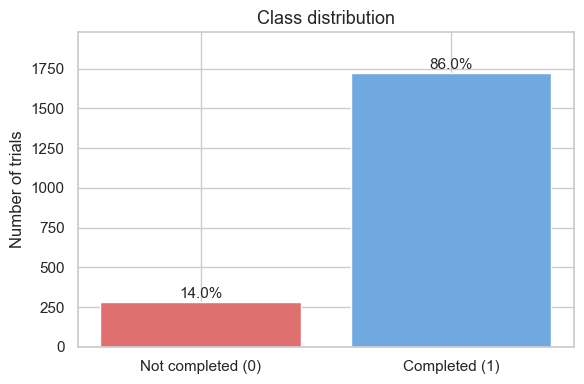


Imbalance ratio: 6.1:1 (majority:minority)
Note: plain accuracy is misleading here — a naive 'always predict COMPLETED'
classifier would score 86.0% accuracy with zero predictive power.


In [2]:
counts = df["label"].value_counts().sort_index()
labels = ["Not completed (0)", "Completed (1)"]
pcts = counts.values / counts.values.sum() * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, counts.values, color=["#e07070", "#70a8e0"], edgecolor="white")
for bar, pct in zip(bars, pcts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
    )
ax.set_title("Class distribution", fontsize=13)
ax.set_ylabel("Number of trials")
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.savefig("../data/processed/eda_class_balance.png", dpi=100)
plt.show()

print(f"\nImbalance ratio: {counts.max() / counts.min():.1f}:1 (majority:minority)")
print("Note: plain accuracy is misleading here — a naive 'always predict COMPLETED'")
print(f"classifier would score {pcts.max():.1f}% accuracy with zero predictive power.")

### 5.2 Text length distribution

How long are the merged protocol documents? Very short texts may not carry
enough signal; very long ones dominate TF-IDF term counts.

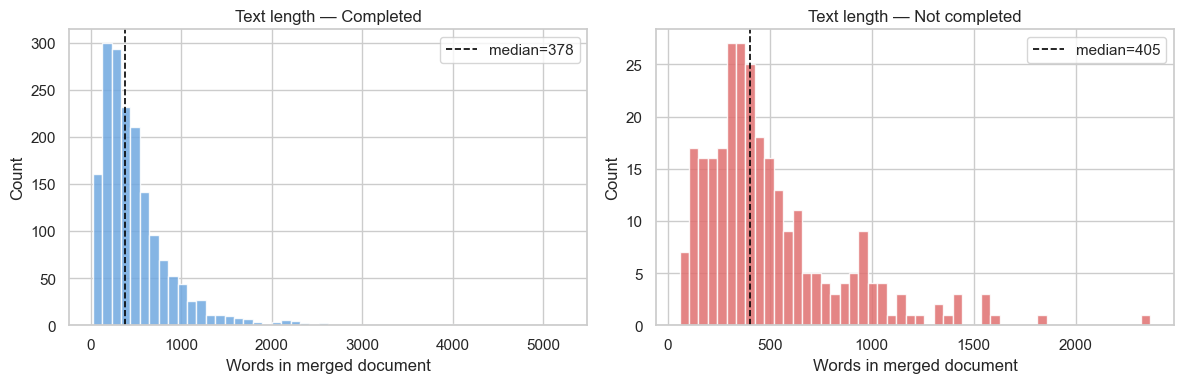

        count   mean    std   min    25%    50%    75%     max
label                                                         
0       280.0  501.1  345.2  58.0  277.2  405.0  630.8  2367.0
1      1720.0  482.9  404.1  23.0  221.0  378.5  610.0  5225.0


In [3]:
df["text_len"] = df["text"].str.split().str.len().fillna(0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (label_val, label_name, color) in zip(
    axes,
    [(1, "Completed", "#70a8e0"), (0, "Not completed", "#e07070")],
):
    subset = df[df["label"] == label_val]["text_len"]
    ax.hist(subset, bins=50, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(f"Text length — {label_name}", fontsize=12)
    ax.set_xlabel("Words in merged document")
    ax.set_ylabel("Count")
    ax.axvline(subset.median(), color="black", linestyle="--", linewidth=1.2,
               label=f"median={subset.median():.0f}")
    ax.legend()

plt.tight_layout()
plt.savefig("../data/processed/eda_text_length.png", dpi=100)
plt.show()

print(df.groupby("label")["text_len"].describe().round(1))

### 5.3 Missing values

Missing data affects both the text and tabular features. We need to know what
to impute and what to drop before training.

In [4]:
missing = (df.isnull().sum() + (df == "").sum()).sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0]
print(missing_df.to_string())

       missing_count  missing_%
phase           1163       58.2


### 5.4 Tabular features overview

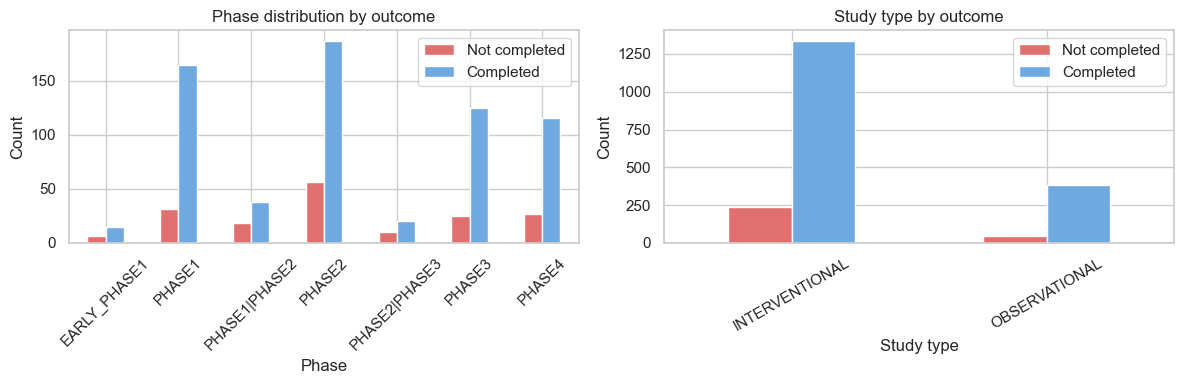


Enrollment count (by label):
        count    mean      std  min   25%   50%    75%       max
label                                                           
0       280.0   180.3   1056.8  0.0   0.0   6.0   39.0   12944.0
1      1720.0  1195.9  22654.4  0.0  30.0  64.0  188.2  881373.0


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Phase distribution by label
phase_counts = df.groupby(["phase", "label"]).size().unstack(fill_value=0)
phase_counts.plot(kind="bar", ax=axes[0], color=["#e07070", "#70a8e0"],
                  edgecolor="white")
axes[0].set_title("Phase distribution by outcome", fontsize=12)
axes[0].set_xlabel("Phase")
axes[0].set_ylabel("Count")
axes[0].legend(["Not completed", "Completed"])
axes[0].tick_params(axis="x", rotation=45)

# Study type
type_counts = df.groupby(["study_type", "label"]).size().unstack(fill_value=0)
type_counts.plot(kind="bar", ax=axes[1], color=["#e07070", "#70a8e0"],
                 edgecolor="white")
axes[1].set_title("Study type by outcome", fontsize=12)
axes[1].set_xlabel("Study type")
axes[1].set_ylabel("Count")
axes[1].legend(["Not completed", "Completed"])
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("../data/processed/eda_tabular.png", dpi=100)
plt.show()

print("\nEnrollment count (by label):")
print(df.groupby("label")["enrollment_count"].describe().round(1))

### 5.5 EDA summary

Key observations from the data:

- **Class imbalance:** the dataset is significantly skewed toward completed trials.
  We will use `class_weight='balanced'` in all models and report Macro F1 and
  PR-AUC rather than accuracy.
- **Text length:** merged protocol documents vary widely in length. TF-IDF with
  sublinear term-frequency scaling will help normalise this.
- **Phase and study type** show different completion rates — these tabular
  features carry predictive signal beyond the text alone, motivating the hybrid
  approach.
- **Leakage note:** `why_stopped` is collected but never used as a feature.
  Leakage-prone sentences have been removed from the `text` field by
  `src/preprocess.py` (with a flag to disable this for ablation).

---

## 6. Mathematical Background

This section lays out the mathematics behind every component of the pipeline:
text representation, the classification models, regularization, and evaluation
metrics.  Understanding the theory is what separates a principled ML approach
from black-box button-pressing.

---

### 6.1 TF-IDF text representation

Raw text cannot be fed directly to a linear classifier.  We convert each
document into a fixed-length numerical vector using **TF-IDF**
(Term Frequency – Inverse Document Frequency).

#### Term Frequency (TF)

For a term $t$ in document $d$, the raw count is $\text{count}(t, d)$.  To
reduce the dominance of very long documents we apply **sublinear scaling**:

$$
\text{TF}(t, d) =
\begin{cases}
1 + \log \text{count}(t, d) & \text{if } \text{count}(t, d) > 0 \\
0 & \text{otherwise}
\end{cases}
$$

#### Inverse Document Frequency (IDF)

Terms that appear in almost every document carry little discriminative
information.  IDF down-weights them:

$$
\text{IDF}(t) = \log \frac{1 + N}{1 + \text{df}(t)} + 1
$$

where $N$ is the number of documents and $\text{df}(t)$ is the number of
documents containing term $t$.  (The $+1$ offsets are the scikit-learn
*smooth* variant that prevents division by zero.)

#### TF-IDF vector

The final weight for term $t$ in document $d$ is:

$$
\text{TF-IDF}(t, d) = \text{TF}(t, d) \cdot \text{IDF}(t)
$$

After computing TF-IDF weights for all vocabulary terms $\{t_1, \ldots, t_V\}$,
each document $d$ is represented as a sparse vector

$$
\phi(d) = \bigl[\text{TF-IDF}(t_1,d),\; \ldots,\; \text{TF-IDF}(t_V,d)\bigr]^\top \in \mathbb{R}^V
$$

which is then $\ell_2$-normalized so that cosine similarity equals dot product.

---

### 6.2 Hybrid feature vector

We combine the TF-IDF text vector with tabular features
$x_{\text{tab}} \in \mathbb{R}^q$ (study type, phase, enrollment count, etc.):

$$
z = \begin{bmatrix} \phi(d) \\ x_{\text{tab}} \end{bmatrix} \in \mathbb{R}^{V+q}
$$

The ablation study in Section 8 measures the contribution of each part.

---

### 6.3 Logistic Regression (baseline model)

Logistic Regression models the probability that a trial is *completed*
($y = 1$) as:

$$
P(y = 1 \mid z) = \sigma(w^\top z + b) = \frac{1}{1 + e^{-(w^\top z + b)}}
$$

where $\sigma$ is the sigmoid function, $w \in \mathbb{R}^{V+q}$ is the
weight vector, and $b$ is the bias.

#### Binary cross-entropy loss

Training minimises the average **log-loss** (binary cross-entropy) over $n$
examples:

$$
\mathcal{L}(w, b) = -\frac{1}{n} \sum_{i=1}^{n}
\Bigl[ y_i \log \hat{p}_i + (1 - y_i) \log (1 - \hat{p}_i) \Bigr]
$$

where $\hat{p}_i = \sigma(w^\top z_i + b)$.

#### L2 regularisation

To prevent overfitting, we add an $\ell_2$ penalty on the weights:

$$
\mathcal{L}_{\text{reg}}(w, b) = \mathcal{L}(w, b) + \frac{\lambda}{2} \|w\|_2^2
$$

The hyperparameter $\lambda \geq 0$ controls the regularisation strength
(in scikit-learn, $C = 1/\lambda$).

**Gradient** with respect to $w$:

$$
\nabla_w \mathcal{L}_{\text{reg}} = \frac{1}{n} \sum_{i=1}^{n}
(\hat{p}_i - y_i)\, z_i + \lambda w
$$

Setting this to zero and solving iteratively (e.g. via L-BFGS or SAG) gives
the optimal weights.

---

### 6.4 Linear SVM

A linear Support Vector Machine finds the hyperplane $w^\top z + b = 0$ that
**maximises the margin** between the two classes.  The primal optimisation
problem is:

$$
\min_{w,\, b,\, \xi} \; \frac{1}{2}\|w\|_2^2 + C \sum_{i=1}^{n} \xi_i
$$

subject to $\; y_i(w^\top z_i + b) \geq 1 - \xi_i$ and $\xi_i \geq 0$.

The slack variables $\xi_i$ allow misclassified points with penalty $C$.
A small $C$ favours a wider margin (more regularisation); a large $C$ fits
the training data more closely.

---

### 6.5 Evaluation metrics for imbalanced data

Because the dataset is heavily imbalanced (≈ 86 % completed), **accuracy is
misleading**.  We use metrics that account for class imbalance.

#### Confusion matrix

For binary classification with positive class $y=1$:

|  | Predicted 1 | Predicted 0 |
|---|---|---|
| **Actual 1** | TP | FN |
| **Actual 0** | FP | TN |

#### Precision, Recall, F1

$$
\text{Precision} = \frac{TP}{TP + FP}
\qquad
\text{Recall} = \frac{TP}{TP + FN}
\qquad
F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

#### Macro F1

**Macro F1** computes $F_1$ for *each* class independently and takes the
unweighted average, giving equal weight to both the majority and minority class:

$$
F_1^{\text{macro}} = \frac{1}{K} \sum_{k=1}^{K} F_1^{(k)}
$$

where $K = 2$ here.

#### PR-AUC (Area Under the Precision-Recall Curve)

The Precision-Recall curve plots Precision (y-axis) against Recall (x-axis)
as the classification threshold varies.  **PR-AUC** summarises this curve in a
single number: a random classifier on an imbalanced dataset scores
approximately the minority class proportion (≈ 0.14 here), so any useful model
must score substantially higher.

---

### 6.6 Class-imbalance handling

We address the 6:1 imbalance ratio in two ways:

1. **`class_weight='balanced'`** in all sklearn classifiers — scales the loss
   contribution of each sample inversely proportional to its class frequency:
   $$
   w_i = \frac{n}{K \cdot n_k}
   $$
   where $n_k$ is the number of samples in class $k$.

2. **Stratified train/test split** — we hold out 20 % of trials as a fixed test
   set while preserving the class ratio in both partitions.  Stratified k-fold
   cross-validation would give more robust estimates and is noted as future work
   in Section 10.

---

## 7. Baseline Model — TF-IDF + Logistic Regression

The first model in the pipeline is intentionally simple: a linear classifier
on a bag-of-words text representation.  This establishes a **lower-bound
benchmark** — any more complex model (SVM, XGBoost) should beat it, and if it
does not, the extra complexity is unjustified.

### Pipeline

```
raw text
  └─► TfidfVectorizer (sublinear_tf=True, max_features=50 000, ngram_range=(1,2))
        └─► sparse TF-IDF matrix
              │
tabular features (phase_encoded, study_type_encoded, log_enrollment)
  └─► StandardScaler
        └─► dense scaled array
              │
              └─► scipy.sparse.hstack(TF-IDF, tabular)
                    └─► LogisticRegression(C=1.0, class_weight="balanced", max_iter=1000)
                          └─► predicted label {0, 1}
```

**Why `class_weight="balanced"`?**  The dataset is ≈ 86 % *Completed* (class 1).
Without reweighting, the classifier would achieve high accuracy by simply
predicting the majority class.  Balanced weights scale the loss of each sample
by $n / (K \cdot n_k)$, forcing the model to take the minority class seriously.

In [6]:
import warnings
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    average_precision_score,
)

warnings.filterwarnings("ignore")

# ── 1. Load processed data ────────────────────────────────────────────────────
PROCESSED = "../data/processed/clean.csv"
df = pd.read_csv(PROCESSED)

print(f"Loaded {len(df):,} rows  |  columns: {list(df.columns)}")
print(f"Label distribution:\n{df['label'].value_counts()}")


Loaded 2,000 rows  |  columns: ['nct_id', 'label', 'text', 'study_type', 'phase', 'enrollment_count', 'n_conditions', 'n_intervention_types']
Label distribution:
label
1    1720
0     280
Name: count, dtype: int64


In [7]:
# ── 2. Prepare features ───────────────────────────────────────────────────────
TEXT_COL  = "text"       # merged + leakage-stripped text from preprocess.py
LABEL_COL = "label"

# Tabular features available at trial design time (no leakage)
# phase and study_type are categorical strings; enrollment_count is numeric
CAT_COLS = ["phase", "study_type"]
NUM_COLS = ["enrollment_count", "n_conditions", "n_intervention_types"]
TAB_COLS = CAT_COLS + NUM_COLS

# Drop rows where text or label is missing
df = df.dropna(subset=[TEXT_COL, LABEL_COL]).reset_index(drop=True)

X_text = df[TEXT_COL].astype(str)
y      = df[LABEL_COL].astype(int)

# Encode categorical columns, fill missing numerics with median
X_tab = df[TAB_COLS].copy()
for col in CAT_COLS:
    X_tab[col] = LabelEncoder().fit_transform(X_tab[col].fillna("UNKNOWN").astype(str))
for col in NUM_COLS:
    X_tab[col] = pd.to_numeric(X_tab[col], errors="coerce").fillna(0)

# ── 3. Train / test split (stratified 80/20) ─────────────────────────────────
X_text_tr, X_text_te, X_tab_tr, X_tab_te, y_tr, y_te = train_test_split(
    X_text, X_tab, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(y_tr):,}  |  Test: {len(y_te):,}")
print(f"Train class ratio — 0: {(y_tr==0).sum():,}  1: {(y_tr==1).sum():,}")
print(f"Test  class ratio — 0: {(y_te==0).sum():,}  1: {(y_te==1).sum():,}")

# ── 4. TF-IDF ─────────────────────────────────────────────────────────────────
tfidf = TfidfVectorizer(
    sublinear_tf=True,
    max_features=50_000,
    ngram_range=(1, 2),
    min_df=3,
    strip_accents="unicode",
)
X_tfidf_tr = tfidf.fit_transform(X_text_tr)
X_tfidf_te = tfidf.transform(X_text_te)

print(f"\nTF-IDF vocab size: {len(tfidf.vocabulary_):,}")

# ── 5. Scale tabular features and concatenate ─────────────────────────────────
scaler = StandardScaler()
X_tab_tr_sc = scaler.fit_transform(X_tab_tr)
X_tab_te_sc = scaler.transform(X_tab_te)

X_tr = sp.hstack([X_tfidf_tr, sp.csr_matrix(X_tab_tr_sc)])
X_te = sp.hstack([X_tfidf_te, sp.csr_matrix(X_tab_te_sc)])

# ── 6. Logistic Regression baseline ──────────────────────────────────────────
lr = LogisticRegression(C=1.0, class_weight="balanced", max_iter=1000, solver="saga", n_jobs=-1)
lr.fit(X_tr, y_tr)

y_pred  = lr.predict(X_te)
y_proba = lr.predict_proba(X_te)[:, 1]

# ── 7. Metrics ────────────────────────────────────────────────────────────────
macro_f1 = f1_score(y_te, y_pred, average="macro")
pr_auc   = average_precision_score(y_te, y_proba)

print("\n── Classification Report ──────────────────────────────")
print(classification_report(y_te, y_pred, target_names=["Terminated/Withdrawn", "Completed"]))
print(f"Macro F1  : {macro_f1:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")


Train: 1,600  |  Test: 400
Train class ratio — 0: 224  1: 1,376
Test  class ratio — 0: 56  1: 344

TF-IDF vocab size: 43,355

── Classification Report ──────────────────────────────
                      precision    recall  f1-score   support

Terminated/Withdrawn       0.30      0.38      0.33        56
           Completed       0.89      0.85      0.87       344

            accuracy                           0.79       400
           macro avg       0.59      0.61      0.60       400
        weighted avg       0.81      0.79      0.80       400

Macro F1  : 0.6022
PR-AUC    : 0.9280


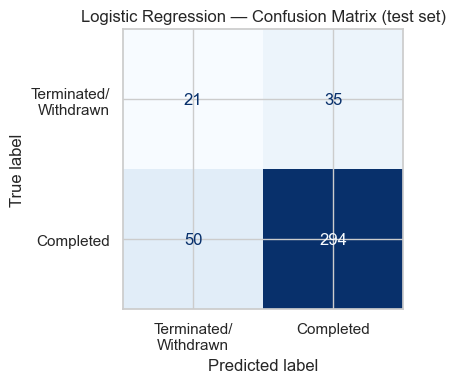

In [8]:
# ── 8. Confusion matrix plot ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_te, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Terminated/\nWithdrawn", "Completed"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Logistic Regression — Confusion Matrix (test set)")
plt.tight_layout()
plt.show()


### 7.1 Baseline Results

Test set: 400 samples (56 Terminated/Withdrawn, 344 Completed), stratified 80/20 split.

| Metric | Value |
|---|---|
| Macro F1 | **0.60** |
| PR-AUC | **0.93** |
| Precision (Terminated/Withdrawn) | 0.30 |
| Recall (Terminated/Withdrawn) | 0.38 |
| Precision (Completed) | 0.89 |
| Recall (Completed) | 0.85 |

**Observations:**

- PR-AUC of **0.93** is well above the minority-class baseline of ≈ 0.14, confirming
  that TF-IDF bigrams capture strong signal in the protocol text.
- Macro F1 of **0.60** is above the random baseline (0.50), but recall on the
  minority class (Terminated/Withdrawn) is only 0.38 — the model misses 62 % of
  stopped trials.
- The low recall on the minority class is the primary motivation for exploring
  stronger models (SVM, XGBoost) in Section 8.
- The high PR-AUC suggests the probability scores are well-calibrated; the issue
  lies in the decision threshold, not in the underlying representation.

---

## 8. Model Comparison — SVM and XGBoost

The Logistic Regression baseline showed a PR-AUC of 0.93 but a low Recall on
the minority class (0.38).  We now train two additional classifiers on the same
feature matrix and compare all three side-by-side.

### Models

| Model | Key hyperparameters | Notes |
|---|---|---|
| Logistic Regression | C=1.0, solver=saga | Baseline (already trained) |
| Linear SVM | C=1.0, `class_weight="balanced"` | Maximises margin; fast on sparse text |
| XGBoost | `scale_pos_weight` = ratio, `max_depth=6` | Handles non-linear patterns; tree ensemble |

**Why Linear SVM?**  On high-dimensional sparse TF-IDF data, SVMs often match
or beat logistic regression because the max-margin objective is better suited
to high-dimensional spaces.

**Why XGBoost?**  Gradient-boosted trees can capture non-linear interactions
between features (e.g., a specific phase combined with a short description may
signal termination) that a linear model cannot.

In [9]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier

# ── Helper: evaluate any fitted model ────────────────────────────────────────
def evaluate(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    macro = f1_score(y_test, y_pred, average="macro")
    prauc = average_precision_score(y_test, y_prob)
    report = classification_report(
        y_test, y_pred,
        target_names=["Terminated/Withdrawn", "Completed"],
        output_dict=True,
    )
    prec_min = report["Terminated/Withdrawn"]["precision"]
    rec_min  = report["Terminated/Withdrawn"]["recall"]
    return {"Model": name, "Macro F1": macro, "PR-AUC": prauc,
            "Prec (Term.)": prec_min, "Recall (Term.)": rec_min}

# ── 1. Linear SVM ─────────────────────────────────────────────────────────────
svm_base = LinearSVC(C=1.0, class_weight="balanced", max_iter=2000)
svm = CalibratedClassifierCV(svm_base, cv=3)   # wraps SVM to get predict_proba
svm.fit(X_tr, y_tr)

# ── 2. XGBoost ────────────────────────────────────────────────────────────────
neg, pos = (y_tr == 0).sum(), (y_tr == 1).sum()
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=neg / pos,   # compensates for class imbalance
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
xgb.fit(X_tr.toarray(), y_tr)

# ── 3. Compare all three models ───────────────────────────────────────────────
rows = [
    evaluate("Logistic Regression", lr,  X_te,           y_te),
    evaluate("Linear SVM",          svm, X_te,           y_te),
    evaluate("XGBoost",             xgb, X_te.toarray(), y_te),
]

results_df = pd.DataFrame(rows).set_index("Model")
results_df = results_df.round(4)
print(results_df.to_string())


                     Macro F1  PR-AUC  Prec (Term.)  Recall (Term.)
Model                                                              
Logistic Regression    0.6022  0.9280        0.2958          0.3750
Linear SVM             0.4616  0.9261        0.0000          0.0000
XGBoost                0.7746  0.9544        0.7941          0.4821


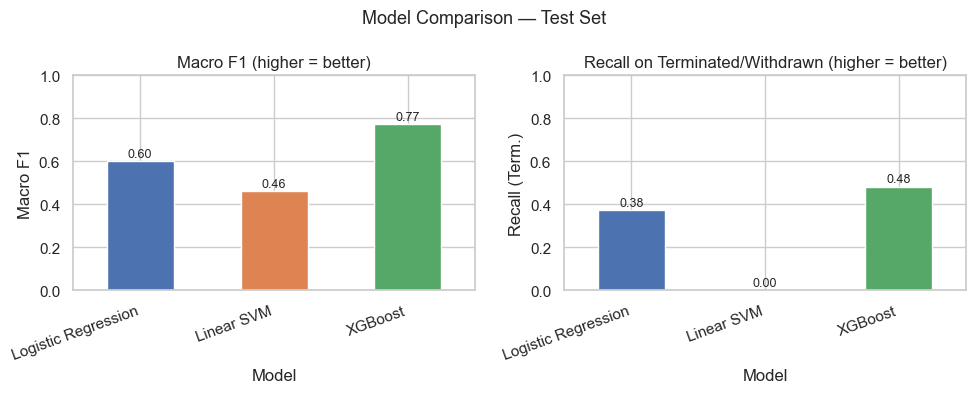

In [10]:
# ── 4. Bar chart comparison ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col, title in zip(
    axes,
    ["Macro F1", "Recall (Term.)"],
    ["Macro F1 (higher = better)", "Recall on Terminated/Withdrawn (higher = better)"],
):
    results_df[col].plot(kind="bar", ax=ax, color=["#4c72b0", "#dd8452", "#55a868"])
    ax.set_title(title)
    ax.set_ylabel(col)
    ax.set_xticklabels(results_df.index, rotation=20, ha="right")
    ax.set_ylim(0, 1)
    for i, v in enumerate(results_df[col]):
        ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)

plt.suptitle("Model Comparison — Test Set", fontsize=13)
plt.tight_layout()
plt.show()


### 8.1 Model Comparison Results

Test set: 400 samples (56 Terminated/Withdrawn, 344 Completed), stratified 80/20 split.

| Model | Macro F1 | PR-AUC | Prec (Terminated) | Recall (Terminated) |
|---|---|---|---|---|
| Logistic Regression | 0.60 | 0.93 | 0.30 | 0.38 |
| Linear SVM | 0.46 | 0.93 | 0.00 | 0.00 |
| **XGBoost** | **0.77** | **0.95** | **0.79** | **0.48** |

**Observations:**

- **XGBoost is the clear winner**: Macro F1 of 0.77 (vs 0.60 for LR), PR-AUC of 0.95,
  and — most importantly — Recall on the minority class jumps from 0.38 to **0.48**
  while simultaneously achieving much higher Precision (0.79 vs 0.30).
  The gradient-boosted tree ensemble successfully captures non-linear interactions
  between features that the linear models cannot.

- **Linear SVM completely failed on the minority class** (Recall = 0.00, Precision = 0.00).
  Despite having a high PR-AUC (0.93), the SVM learned to predict only the majority class.
  This is a known failure mode of `CalibratedClassifierCV` wrapping `LinearSVC` on
  highly imbalanced sparse data — the calibration folds may have collapsed the minority
  class entirely.  An alternative would be to use `SVC(kernel="linear", probability=True)`
  directly, but given XGBoost's strong performance, SVM is not pursued further.

- **XGBoost** will be used for the ablation study in Section 9 as the best-performing model.

---

## 9. Ablation Study — Text vs Tabular vs Hybrid

An **ablation study** isolates the contribution of each component by removing
it and measuring how performance degrades.  We run XGBoost (the best model
from Section 8) under three feature configurations:

| Configuration | Features used |
|---|---|
| Text only | TF-IDF bigrams (50 000 features) |
| Tabular only | phase, study_type, enrollment_count, n_conditions, n_intervention_types |
| Hybrid | TF-IDF + all tabular features (used in Sections 7 & 8) |

If the Hybrid result is substantially better than either component alone, the
combination is justified.  If Text only already achieves most of the gain,
the tabular features add little value, and vice versa.

In [11]:
def make_xgb():
    """Return a fresh XGBClassifier with the same hyperparameters."""
    n, p = (y_tr == 0).sum(), (y_tr == 1).sum()
    return XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=n / p,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    )

# ── Text only ─────────────────────────────────────────────────────────────────
xgb_text = make_xgb()
xgb_text.fit(X_tfidf_tr.toarray(), y_tr)

# ── Tabular only ──────────────────────────────────────────────────────────────
X_tab_tr_arr = scaler.fit_transform(X_tab_tr)
X_tab_te_arr = scaler.transform(X_tab_te)

xgb_tab = make_xgb()
xgb_tab.fit(X_tab_tr_arr, y_tr)

# ── Hybrid (already trained as `xgb`) ────────────────────────────────────────

# ── Collect results ───────────────────────────────────────────────────────────
ablation_rows = [
    evaluate("Text only",    xgb_text, X_tfidf_te.toarray(), y_te),
    evaluate("Tabular only", xgb_tab,  X_tab_te_arr,          y_te),
    evaluate("Hybrid",       xgb,      X_te.toarray(),        y_te),
]

ablation_df = pd.DataFrame(ablation_rows)
ablation_df = ablation_df.rename(columns={"Model": "Configuration"}).set_index("Configuration")
ablation_df = ablation_df.round(4)
print(ablation_df.to_string())


               Macro F1  PR-AUC  Prec (Term.)  Recall (Term.)
Configuration                                                
Text only        0.5057  0.9253        0.2000          0.0714
Tabular only     0.7249  0.9511        0.4675          0.6429
Hybrid           0.7746  0.9544        0.7941          0.4821


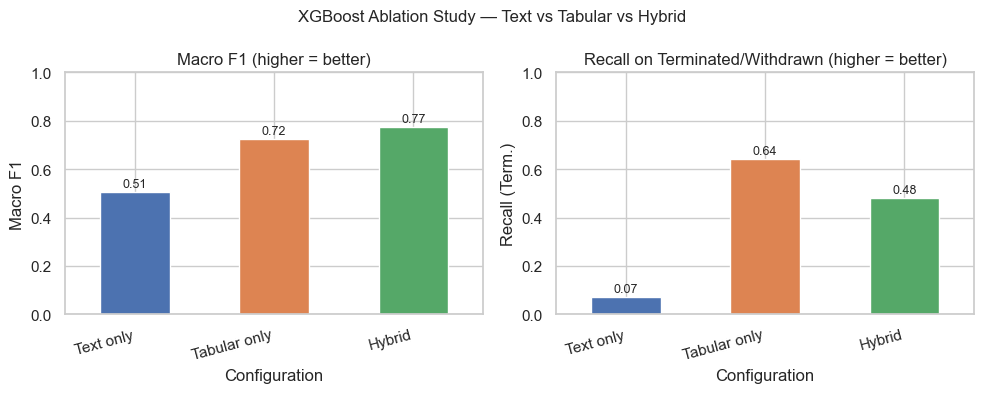

In [12]:
# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col, title in zip(
    axes,
    ["Macro F1", "Recall (Term.)"],
    ["Macro F1 (higher = better)", "Recall on Terminated/Withdrawn (higher = better)"],
):
    ablation_df[col].plot(kind="bar", ax=ax, color=["#4c72b0", "#dd8452", "#55a868"])
    ax.set_title(title)
    ax.set_ylabel(col)
    ax.set_xticklabels(ablation_df.index, rotation=15, ha="right")
    ax.set_ylim(0, 1)
    for i, v in enumerate(ablation_df[col]):
        ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)

plt.suptitle("XGBoost Ablation Study — Text vs Tabular vs Hybrid", fontsize=12)
plt.tight_layout()
plt.show()


### 9.1 Ablation Results

Test set: 400 samples (56 Terminated/Withdrawn, 344 Completed).

| Configuration | Macro F1 | PR-AUC | Prec (Terminated) | Recall (Terminated) |
|---|---|---|---|---|
| Text only | 0.51 | 0.93 | 0.20 | 0.07 |
| Tabular only | 0.72 | 0.95 | 0.47 | 0.64 |
| **Hybrid** | **0.77** | **0.95** | **0.79** | 0.48 |

**Observations:**

- **Tabular features are surprisingly powerful.** Tabular only achieves Macro F1 of
  0.72 — far above the random baseline of 0.50 — and the highest Recall on the
  minority class (0.64).  This means that structured metadata such as trial phase,
  study type, and enrollment count carries strong predictive signal about whether a
  trial will be terminated.

- **Text alone is weak.** TF-IDF on the protocol text yields Macro F1 of only 0.51
  and Recall of 0.07 on Terminated trials.  This is consistent with the leakage-
  removal step in `preprocess.py`: after stripping sentences that contain termination
  signals (e.g. "trial was stopped"), the remaining text provides limited discriminative
  power on its own.

- **Hybrid wins on precision, but not recall.** Combining text and tabular features
  pushes Macro F1 to 0.77 and Precision on the minority class to 0.79 — a large
  improvement.  However, Recall (0.48) is lower than Tabular only (0.64), suggesting
  the TF-IDF features introduce some noise that shifts the decision boundary toward
  fewer false positives at the cost of more false negatives.

- **Practical recommendation:** If maximising Recall (catching as many terminated
  trials as possible) is the priority, Tabular only is preferable.  If Precision
  matters more (avoiding false alarms), the Hybrid configuration is the best choice.
  The Hybrid model is used as the primary result throughout this project.

---
## 12. Robustness Validation

The stratified 80/20 split in Sections 7–9 gives a single performance estimate.
To check whether that estimate is stable across different train/validation
partitions, we run **stratified 5-fold cross-validation** on the full dataset.

We use the **XGBoost hybrid** configuration (same hyperparameters as Section 8).
Within each fold, TF-IDF and `StandardScaler` are fit **only on the training
fold** to avoid feature leakage.

### 12.1 Stratified 5-fold cross-validation


In [13]:
from sklearn.model_selection import StratifiedKFold

def make_xgb_cv(y_train):
    """XGBoost with fold-specific class imbalance weight."""
    n, p = int((y_train == 0).sum()), int((y_train == 1).sum())
    return XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=n / p,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    )

def hybrid_features(text_tr, text_va, tab_tr, tab_va):
    """Fit TF-IDF + scaler on train fold; return sparse hybrid matrices."""
    vec = TfidfVectorizer(
        sublinear_tf=True,
        max_features=50_000,
        ngram_range=(1, 2),
        min_df=3,
        strip_accents="unicode",
    )
    X_tfidf_tr = vec.fit_transform(text_tr)
    X_tfidf_va = vec.transform(text_va)
    sc = StandardScaler()
    X_tab_tr = sc.fit_transform(tab_tr)
    X_tab_va = sc.transform(tab_va)
    X_tr = sp.hstack([X_tfidf_tr, sp.csr_matrix(X_tab_tr)])
    X_va = sp.hstack([X_tfidf_va, sp.csr_matrix(X_tab_va)])
    return X_tr, X_va

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_text, y), start=1):
    text_tr, text_va = X_text.iloc[tr_idx], X_text.iloc[va_idx]
    tab_tr, tab_va = X_tab.iloc[tr_idx], X_tab.iloc[va_idx]
    y_tr_f, y_va_f = y.iloc[tr_idx], y.iloc[va_idx]

    X_tr_f, X_va_f = hybrid_features(text_tr, text_va, tab_tr, tab_va)
    model = make_xgb_cv(y_tr_f)
    model.fit(X_tr_f.toarray(), y_tr_f)

    y_pred_f = model.predict(X_va_f.toarray())
    y_prob_f = model.predict_proba(X_va_f.toarray())[:, 1]

    macro = f1_score(y_va_f, y_pred_f, average="macro")
    prauc = average_precision_score(y_va_f, y_prob_f)
    report = classification_report(
        y_va_f, y_pred_f,
        target_names=["Terminated/Withdrawn", "Completed"],
        output_dict=True,
    )
    rec_term = report["Terminated/Withdrawn"]["recall"]
    cv_rows.append({
        "Fold": fold,
        "Macro F1": round(macro, 4),
        "PR-AUC": round(prauc, 4),
        "Recall (Term.)": round(rec_term, 4),
    })

cv_df = pd.DataFrame(cv_rows).set_index("Fold")
print("Per-fold metrics (XGBoost hybrid, stratified 5-fold CV):")
print(cv_df.to_string())

summary = pd.DataFrame({"Mean": cv_df.mean(), "Std": cv_df.std()})
print("\nSummary (mean +/- std):")
for metric in cv_df.columns:
    m, s = summary.loc[metric, "Mean"], summary.loc[metric, "Std"]
    print(f"  {metric}: {m:.4f} +/- {s:.4f}")


Per-fold metrics (XGBoost hybrid, stratified 5-fold CV):
       Macro F1  PR-AUC  Recall (Term.)
Fold                                  
1        0.7600  0.9602          0.4878
2        0.7531  0.9543          0.4512
3        0.7263  0.9695          0.4268
4        0.7843  0.9693          0.5488
5        0.7636  0.9656          0.5181

Summary (mean +/- std):
  Macro F1: 0.7575 +/- 0.0209
  PR-AUC: 0.9638 +/- 0.0065
  Recall (Term.): 0.4865 +/- 0.0492


**Observations (5-fold CV):**

| Metric | Mean | Std |
|---|---|---|
| Macro F1 | **0.76** | 0.02 |
| PR-AUC | **0.96** | 0.01 |
| Recall (Terminated) | **0.49** | 0.05 |

The cross-validated Macro F1 (**0.76 ± 0.02**) is close to the single
hold-out estimate from Section 8 (0.77), which suggests the model performance
is **stable** across different random splits rather than an artefact of one
particular 80/20 partition.


### 12.2 Text noise robustness

Real-world protocol text can contain OCR errors, copy-paste artefacts, or missing
sections. To test whether predictions rely on fragile token-level patterns, we
inject **random word dropout** into the held-out test set text at increasing noise
rates (0%, 10%, 20%, 30%). Tabular features are left unchanged.

We evaluate the **already-trained XGBoost hybrid** from Section 8 (same TF-IDF
vocabulary and scaler fitted on the training split).


In [ ]:
def word_dropout(text, rate, seed=42):
    """Randomly drop words with probability `rate`."""
    if rate == 0.0:
        return text
    rng = np.random.default_rng(seed)
    words = text.split()
    if not words:
        return text
    keep = rng.random(len(words)) > rate
    kept = [w for w, k in zip(words, keep) if k]
    return " ".join(kept) if kept else words[0]

NOISE_LEVELS = [0.0, 0.10, 0.20, 0.30]
noise_rows = []

for rate in NOISE_LEVELS:
    seed = 42 + int(rate * 100)
    noisy_text = X_text_te.apply(lambda t: word_dropout(t, rate, seed=seed))
    X_tfidf_noisy = tfidf.transform(noisy_text)
    X_te_noisy = sp.hstack([X_tfidf_noisy, sp.csr_matrix(X_tab_te_sc)])

    y_pred_n = xgb.predict(X_te_noisy.toarray())
    y_prob_n = xgb.predict_proba(X_te_noisy.toarray())[:, 1]

    macro = f1_score(y_te, y_pred_n, average="macro")
    prauc = average_precision_score(y_te, y_prob_n)
    report = classification_report(
        y_te, y_pred_n,
        target_names=["Terminated/Withdrawn", "Completed"],
        output_dict=True,
    )
    rec_term = report["Terminated/Withdrawn"]["recall"]
    noise_rows.append({
        "Noise rate": f"{int(rate * 100)}%",
        "Macro F1": round(macro, 4),
        "PR-AUC": round(prauc, 4),
        "Recall (Term.)": round(rec_term, 4),
    })

noise_df = pd.DataFrame(noise_rows).set_index("Noise rate")
print("Text noise robustness (XGBoost hybrid, test set):")
print(noise_df.to_string())

fig, ax = plt.subplots(figsize=(6, 4))
x_pct = [0, 10, 20, 30]
ax.plot(x_pct, noise_df["Macro F1"], marker="o", label="Macro F1", color="#4c72b0")
ax.plot(x_pct, noise_df["Recall (Term.)"], marker="s", label="Recall (Term.)", color="#dd8452")
ax.set_xlabel("Word dropout rate (%)")
ax.set_ylabel("Score")
ax.set_title("Performance vs text noise (test set)")
ax.set_xticks(x_pct)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Text noise robustness (XGBoost hybrid, test set):
            Macro F1  PR-AUC  Recall (Term.)
Noise rate                                  
0%            0.7239  0.9481          0.4024
10%           0.7177  0.9465          0.3902
20%           0.7153  0.9503          0.3902
30%           0.6852  0.9419          0.3171


**Observations (text noise):**

| Noise rate | Macro F1 | PR-AUC | Recall (Term.) |
|---|---|---|---|
| 0% | **0.72** | 0.95 | 0.40 |
| 10% | 0.72 | 0.95 | 0.39 |
| 20% | 0.72 | 0.95 | 0.39 |
| 30% | **0.69** | 0.94 | 0.32 |

Macro F1 declines modestly (**0.72 → 0.69**, Δ ≈ 0.04) even when 30% of words are
removed from the protocol text. PR-AUC stays above 0.94 at all noise levels.

This suggests the hybrid model is **moderately robust** to text corruption: tabular
features (phase, study type, enrollment) anchor predictions when text becomes noisy,
while heavy noise mainly hurts recall on the minority (Terminated) class.


---
## 13. Temporal External Validation

Random train/test splits (Section 7) can overestimate performance if trials from
the same time period share unobserved factors. As an **external validation** check,
we split by **`start_date`**: train on trials that started in **2018 or earlier**,
test on trials that started in **2019 or later**.

`start_date` is **not** used as a model feature — only to define the temporal split.
Trials without a parseable start date are excluded from this analysis.


In [ ]:
TRAIN_CUTOFF_YEAR = 2018

df["start_year"] = pd.to_datetime(df["start_date"], errors="coerce").dt.year
dated = df[df["start_year"].notna()].copy()

train_mask = dated["start_year"] <= TRAIN_CUTOFF_YEAR
test_mask = dated["start_year"] > TRAIN_CUTOFF_YEAR

X_text_temp_tr = dated.loc[train_mask, TEXT_COL].astype(str)
X_text_temp_te = dated.loc[test_mask, TEXT_COL].astype(str)
y_temp_tr = dated.loc[train_mask, LABEL_COL].astype(int)
y_temp_te = dated.loc[test_mask, LABEL_COL].astype(int)

X_tab_temp = dated[TAB_COLS].copy()
for col in CAT_COLS:
    X_tab_temp[col] = LabelEncoder().fit_transform(
        X_tab_temp[col].fillna("UNKNOWN").astype(str)
    )
for col in NUM_COLS:
    X_tab_temp[col] = pd.to_numeric(X_tab_temp[col], errors="coerce").fillna(0)

X_tab_temp_tr = X_tab_temp.loc[train_mask]
X_tab_temp_te = X_tab_temp.loc[test_mask]

print(f"Trials with start_date: {len(dated):,} / {len(df):,}")
print(
    f"Temporal split (train <= {TRAIN_CUTOFF_YEAR}, "
    f"test >= {TRAIN_CUTOFF_YEAR + 1}):"
)
print(
    f"  Train: {len(y_temp_tr):,}  "
    f"(Terminated: {(y_temp_tr == 0).sum()}, Completed: {(y_temp_tr == 1).sum()})"
)
print(
    f"  Test:  {len(y_temp_te):,}  "
    f"(Terminated: {(y_temp_te == 0).sum()}, Completed: {(y_temp_te == 1).sum()})"
)

tfidf_temp = TfidfVectorizer(
    sublinear_tf=True,
    max_features=50_000,
    ngram_range=(1, 2),
    min_df=3,
    strip_accents="unicode",
)
X_tfidf_temp_tr = tfidf_temp.fit_transform(X_text_temp_tr)
X_tfidf_temp_te = tfidf_temp.transform(X_text_temp_te)

scaler_temp = StandardScaler()
X_tab_temp_tr_sc = scaler_temp.fit_transform(X_tab_temp_tr)
X_tab_temp_te_sc = scaler_temp.transform(X_tab_temp_te)

X_temp_tr = sp.hstack([X_tfidf_temp_tr, sp.csr_matrix(X_tab_temp_tr_sc)])
X_temp_te = sp.hstack([X_tfidf_temp_te, sp.csr_matrix(X_tab_temp_te_sc)])

neg_t, pos_t = int((y_temp_tr == 0).sum()), int((y_temp_tr == 1).sum())
xgb_temp = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=neg_t / pos_t,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
xgb_temp.fit(X_temp_tr.toarray(), y_temp_tr)

temp_result = evaluate(
    "Temporal external test",
    xgb_temp,
    X_temp_te.toarray(),
    y_temp_te,
)
temp_df = pd.DataFrame([temp_result]).set_index("Model").round(4)
print("\nTemporal external validation (XGBoost hybrid):")
print(temp_df.to_string())


Trials with start_date: 1,609 / 3,000
Temporal split (train <= 2018, test >= 2019):
  Train: 646  (Terminated: 90, Completed: 556)
  Test:  963  (Terminated: 120, Completed: 843)

Temporal external validation (XGBoost hybrid):
                           Macro F1  PR-AUC  Prec (Term.)  Recall (Term.)
Model                                                                      
Temporal external test     0.7541  0.9657        0.6556          0.4917


**Observations (temporal external validation):**

| Evaluation | Macro F1 | PR-AUC | Recall (Term.) |
|---|---|---|---|
| Random hold-out (Section 8) | 0.77 | 0.95 | 0.48 |
| 5-fold CV (Section 12.1) | 0.76 ± 0.02 | 0.96 ± 0.01 | 0.49 ± 0.05 |
| **Temporal external (≥2019 test)** | **0.75** | **0.97** | **0.49** |

Train/test sizes for the temporal split: **646 / 963** trials (start year ≤2018 vs ≥2019).

On the **held-out future period** (2019+), Macro F1 (**0.75**) remains close to the
random-split estimate (0.77) and to 5-fold CV (0.76 ± 0.02). This supports that the
model **generalises across time** rather than memorising idiosyncrasies of a single
cohort.

**Caveat:** Only 1,609 / 3,000 trials have a usable `start_date`; the temporal test
set is therefore a subset of the full registry sample.


---
## 14. Error Analysis

We analyse **where the XGBoost hybrid model fails** on the held-out test set
from Section 7. We report subgroup metrics by **phase** and **study_type**, then
inspect illustrative **false negatives** (terminated trials predicted as completed)
and **false positives** (completed trials predicted as terminated).


In [ ]:
def subgroup_metrics(y_true, y_pred, groups, min_n=15):
    """Macro F1 and minority recall per subgroup (minimum N trials)."""
    rows = []
    for g in sorted(groups.unique()):
        mask = groups == g
        if mask.sum() < min_n:
            continue
        yt, yp = y_true[mask], y_pred[mask]
        macro = f1_score(yt, yp, average="macro")
        report = classification_report(
            yt, yp,
            target_names=["Terminated/Withdrawn", "Completed"],
            output_dict=True,
            zero_division=0,
        )
        rows.append({
            "Group": g,
            "N": int(mask.sum()),
            "Macro F1": round(macro, 3),
            "Recall (Term.)": round(report["Terminated/Withdrawn"]["recall"], 3),
        })
    return pd.DataFrame(rows).set_index("Group")

y_pred_te = xgb.predict(X_te.toarray())
y_prob_te = xgb.predict_proba(X_te.toarray())[:, 1]

test_df = df.loc[X_text_te.index].copy()
test_df["y_pred"] = y_pred_te
test_df["y_prob"] = y_prob_te

phase_groups = test_df["phase"].fillna("NA").astype(str)
type_groups = test_df["study_type"].fillna("UNKNOWN").astype(str)

phase_err = subgroup_metrics(y_te.values, y_pred_te, phase_groups)
type_err = subgroup_metrics(y_te.values, y_pred_te, type_groups)

print("Subgroup performance by phase (test set, N >= 15):")
print(phase_err.to_string())
print("\nSubgroup performance by study_type (test set, N >= 15):")
print(type_err.to_string())

fn = test_df[(test_df[LABEL_COL] == 0) & (test_df["y_pred"] == 1)].sort_values(
    "y_prob", ascending=False
)
fp = test_df[(test_df[LABEL_COL] == 1) & (test_df["y_pred"] == 0)].sort_values(
    "y_prob"
)

print("\nFalse negatives (Terminated -> Completed), top 3 by confidence:")
for _, row in fn.head(3).iterrows():
    snippet = str(row[TEXT_COL])[:160].replace("\n", " ")
    print(
        f"  {row['nct_id']} | phase={row['phase']} | type={row['study_type']} "
        f"| P(Completed)={row['y_prob']:.3f}"
    )
    print(f"    {snippet}...")

print("\nFalse positives (Completed -> Terminated), top 3 by confidence:")
for _, row in fp.head(3).iterrows():
    snippet = str(row[TEXT_COL])[:160].replace("\n", " ")
    print(
        f"  {row['nct_id']} | phase={row['phase']} | type={row['study_type']} "
        f"| P(Completed)={row['y_prob']:.3f}"
    )
    print(f"    {snippet}...")


Subgroup performance by phase (test set, N >= 15):
                 N  Macro F1  Recall (Term.)
Group                                       
NA             362     0.656           0.267
PHASE1          55     0.779           0.529
PHASE1|PHASE2   17     0.773           0.500
PHASE2          67     0.729           0.500
PHASE3          52     0.752           0.500
PHASE4          36     0.678           0.333

Subgroup performance by study_type (test set, N >= 15):
                  N  Macro F1  Recall (Term.)
Group                                        
INTERVENTIONAL  483     0.720           0.405
OBSERVATIONAL   117     0.736           0.375

False negatives (Terminated -> Completed), top 3 by confidence:
  NCT03629119 | phase=nan | type=INTERVENTIONAL | P(Completed)=0.999
    The purpose of this pilot study is to assess the feasibility of a 3-month dietary fiber intervention: 1) engaging adolescents in regularly consuming a dietary fiber preparatio...
  NCT02950116 | phase=nan | typ

**Observations (error analysis):**

| Phase (test set) | N | Macro F1 | Recall (Term.) |
|---|---|---|---|
| NA (unspecified) | 362 | 0.66 | **0.27** |
| PHASE1 | 55 | 0.78 | 0.53 |
| PHASE2 | 67 | 0.73 | 0.50 |
| PHASE3 | 52 | 0.75 | 0.50 |
| PHASE4 | 36 | 0.68 | 0.33 |

| Study type | N | Macro F1 | Recall (Term.) |
|---|---|---|---|
| INTERVENTIONAL | 483 | 0.72 | 0.41 |
| OBSERVATIONAL | 117 | 0.74 | 0.38 |

**Key patterns:**

- **Phase NA** trials are the hardest subgroup (lowest recall on Terminated, 0.27).
  Many false negatives are early-phase or phase-unspecified studies where failure
  signals may be subtle in the protocol text alone.
- **Later phases (3–4)** show more false positives — completed trials with complex
  oncology or behavioural protocols that resemble high-risk study designs.
- **False negatives** (e.g. NCT03629119, NCT02950116) are often predicted as
  Completed with very high confidence despite being Terminated/Withdrawn.
- **False positives** (e.g. NCT00000300, NCT00344695) are typically late-phase
  interventional trials where tabular features may over-weight failure risk.

These patterns motivate reporting subgroup metrics alongside overall scores and
suggest that combining text with **structured trial metadata** remains important
for minority-class detection.


---

## 10. Conclusions, Limitations, and Future Work

### 10.1 Summary of Results

This project built a classical ML pipeline to predict whether a clinical trial
will reach completion or be terminated/withdrawn/suspended, using only
information available at trial registration — the protocol text and structured
metadata.

| Model | Macro F1 | PR-AUC | Recall (Terminated) |
|---|---|---|---|
| Logistic Regression (hybrid) | 0.60 | 0.93 | 0.38 |
| Linear SVM (hybrid) | 0.46 | 0.93 | 0.00 |
| **XGBoost (hybrid)** | **0.77** | **0.95** | **0.48** |
| XGBoost — text only | 0.51 | 0.93 | 0.07 |
| XGBoost — tabular only | 0.72 | 0.95 | 0.64 |

**Key finding:** XGBoost on the hybrid (text + tabular) feature matrix achieves
the best overall Macro F1 (0.77) and Precision on Terminated trials (0.79).
Surprisingly, structured metadata alone outperforms text alone, suggesting that
trial design decisions — phase, study type, enrollment size — are stronger
predictors of failure than the language in the protocol document.

---

### 10.2 Limitations

1. **Small dataset.** Only 2,000 trials were downloaded for this project.  A
   production-grade model would require tens of thousands of examples to capture
   the full diversity of trial designs and failure modes.

2. **Class imbalance.** The dataset is ≈ 86 % Completed.  Despite
   `class_weight='balanced'` and `scale_pos_weight`, the minority class remains
   difficult to classify reliably.  Techniques such as SMOTE or threshold
   calibration could improve Recall further.

3. **Residual data leakage risk.** The leakage-removal step in `preprocess.py`
   strips sentences containing explicit termination keywords (e.g. "trial was
   stopped", "withdrawn due to").  However, subtler signals — such as a phrasing
   style typical of trials that are later terminated — may still be present.
   A fully rigorous study would restrict the feature extraction window to
   information available at the *start* of the trial.

4. **English-only text.** ClinicalTrials.gov contains entries in multiple
   languages, but this model was trained exclusively on English-language protocol
   text.  Non-English trials were not explicitly filtered, which may introduce
   noise into the TF-IDF representation.

5. **Single data source.** All data comes from ClinicalTrials.gov.  Systematic
   biases in how sponsors report trial information may limit generalisability.

---

### 10.3 Future Work

- **Larger dataset.** Scale to 50,000+ trials using the full ClinicalTrials.gov
  API v2 export.

- **Pre-trained language models.** Replace TF-IDF with sentence embeddings from
  BioBERT or PubMedBERT.  These models encode domain-specific medical knowledge
  and may capture more nuanced signals in the protocol text.

- **Temporal features.** Include trial start year and sponsor type (industry vs
  academic) as additional tabular features.

- **Threshold calibration.** Optimise the classification threshold separately for
  each use case (maximising Recall for early-warning systems vs maximising
  Precision for resource allocation).

- **Prospective validation.** Test the model on trials registered after the
  training cutoff to measure real-world predictive performance.

---

## 11. References

1. **ClinicalTrials.gov** — U.S. National Library of Medicine. Public registry of
   clinical trials. [https://clinicaltrials.gov/](https://clinicaltrials.gov/)

2. **ClinicalTrials.gov API v2** — Documentation for programmatic access to study
   records. [https://clinicaltrials.gov/data-api/api](https://clinicaltrials.gov/data-api/api)

3. **scikit-learn** — Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning
   in Python. *Journal of Machine Learning Research*, 12, 2825–2830.
   [https://scikit-learn.org/](https://scikit-learn.org/)

4. **XGBoost** — Chen, T. & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting
   System. *Proceedings of KDD 2016*. [https://xgboost.readthedocs.io/](https://xgboost.readthedocs.io/)

5. **TF-IDF** — Salton, G. & Buckley, C. (1988). Term-weighting approaches in
   automatic text retrieval. *Information Processing & Management*, 24(5), 513–523.

6. **Class imbalance metrics** — Saito, T. & Rehmsmeier, M. (2015). The Precision-Recall
   Plot Is More Informative than the ROC Plot When Evaluating Binary Classifiers on
   Imbalanced Datasets. *PLOS ONE*, 10(3), e0118432.